# US Billionaire Wealth: Scale in Context

A series of four charts that build up from household wealth to Elon Musk.  
Each chart adds one more group, zooming the x-axis out so previous groups shrink toward zero — that shrinking is the point.  
All figures in USD billions. Election-day values (Nov 5, 2024) are approximate.

In [1]:
import matplotlib.pyplot as plt
import matplotlib.transforms as mtransforms
from matplotlib.patches import Patch
import numpy as np

In [2]:
GROUP_BELOW = {
    "label": "Below $1B",
    "type":  "ref",
    "color": "#888888",
    "band":  "#f4f4f4",
    "items": [                                  # (name, USD billions), richest first
        ("S&P 500 median CEO (annual pay)",       0.0171),
        ("Millionaire (net worth)",               0.001),
        ("Median US household (net worth)",       0.000192),
        ("Bachelor's+ household (annual income)", 0.0001327),
    ],
}

GROUP_1B_10B = {
    "label": "$1B – $10B",
    "type":  "ref",
    "color": "#c07000",
    "band":  "#fff7e6",
    "items": [
        ("Michael Jordan",  4.3),
        ("Forbes 400 min.", 3.8),
        ("Taylor Swift",    2.0),
        ("CR7",             1.2),
        ("Messi",           1.0),
    ],
}

GROUP_MULTI = {
    "label": "Multi-billionaires",
    "type":  "billie",
    "band":  "#edf2ff",
    "items": [                                  # (name, election-day, today), richest first
        ("Larry Page",      150, 281),
        ("Sergey Brin",     142, 261),
        ("Jeff Bezos",      206, 249),
        ("Larry Ellison",   175, 201),
        ("Mark Zuckerberg", 201, 187),
        ("Michael Dell",    118, 165),
    ],
}

GROUP_MUSK = {
    "label": "Elon Musk",
    "type":  "musk",
    "band":  "#e6f4ea",
    "items": [
        ("Elon Musk", 264, 813, 1260),          # election-day, pre-IPO, today
    ],
}

COLOR_BEFORE  = "#9aa7b4"
COLOR_PRE_IPO = "#f0a030"
COLOR_NOW     = "#1f6feb"

def fmt(v):
    if v == 0:    return "$0"
    if v < 0.001: return f"${v * 1e6:,.0f}K"
    if v < 1.0:   return f"${v * 1e3:,.1f}M"
    if v < 10:    return f"${v:.1f}B"
    return f"${v:,.0f}B"

In [3]:
def draw_chart(groups, title, ref_pct_baseline=None):
    # ref_pct_baseline: {group_label: baseline_value} — ref bars in that group get a % vs baseline
    rows = []
    group_spans = []

    for g in groups:
        start = len(rows)
        for item in g["items"]:
            rows.append({"item": item, "g": g})
        group_spans.append((g, start, len(rows) - 1))

    n = len(rows)
    bar_h = 0.26

    all_vals = []
    for row in rows:
        item, g = row["item"], row["g"]
        if g["type"] == "ref":
            all_vals.append(item[1])
        else:
            all_vals.extend(item[1:])
    max_val = max(all_vals)
    offset  = max_val * 0.008

    fig, ax = plt.subplots(figsize=(14, max(3.5, n * 0.8)))

    # Background bands per group
    for g, start, end in group_spans:
        ax.axhspan(start - 0.5, end + 0.5, color=g["band"], alpha=0.7, zorder=0)

    # Bars and value labels
    for i, row in enumerate(rows):
        item, g = row["item"], row["g"]
        yi = float(i)

        if g["type"] == "ref":
            _, val = item
            ax.barh(yi, val, height=0.4, color=g["color"], zorder=2)
            label = fmt(val)
            if ref_pct_baseline and g["label"] in ref_pct_baseline:
                base = ref_pct_baseline[g["label"]]
                if val != base:
                    pct = (val / base - 1) * 100
                    sign = "+" if pct >= 0 else ""
                    label += f"  ({sign}{pct:,.0f}%)"
            ax.text(val + offset, yi, label,
                    va="center", ha="left", fontsize=8.5, color="#555")

        elif g["type"] == "billie":
            _, before, now = item
            pct = (now - before) / before * 100
            ax.barh(yi + bar_h, before, height=bar_h, color=COLOR_BEFORE, zorder=2)
            ax.barh(yi - bar_h, now,    height=bar_h, color=COLOR_NOW,    zorder=2)
            ax.text(before + offset, yi + bar_h, fmt(before),
                    va="center", ha="left", fontsize=8.5, color="#555")
            sign = "+" if pct >= 0 else ""
            col  = "#137333" if pct >= 0 else "#b3261e"
            ax.text(now + offset, yi - bar_h, f"{fmt(now)}  ({sign}{pct:.0f}%)",
                    va="center", ha="left", fontsize=8.5, fontweight="bold", color=col)

        else:  # musk
            _, before, pre_ipo, now = item
            pct     = (now     - before) / before * 100
            pct_pre = (pre_ipo - before) / before * 100
            ax.barh(yi + bar_h, before,  height=bar_h, color=COLOR_BEFORE,  zorder=2)
            ax.barh(yi,         pre_ipo, height=bar_h, color=COLOR_PRE_IPO, zorder=2)
            ax.barh(yi - bar_h, now,     height=bar_h, color=COLOR_NOW,     zorder=2)
            ax.text(before  + offset, yi + bar_h, fmt(before),
                    va="center", ha="left", fontsize=8.5, color="#555")
            ax.text(pre_ipo + offset, yi,
                    f"{fmt(pre_ipo)}  (+{pct_pre:.0f}%)",
                    va="center", ha="left", fontsize=8.5, fontweight="bold", color="#a06000")
            sign = "+" if pct >= 0 else ""
            col  = "#137333" if pct >= 0 else "#b3261e"
            ax.text(now + offset, yi - bar_h, f"{fmt(now)}  ({sign}{pct:.0f}%)",
                    va="center", ha="left", fontsize=8.5, fontweight="bold", color=col)

    # Separator lines and group labels
    trans = mtransforms.blended_transform_factory(ax.transAxes, ax.transData)
    for g, start, end in group_spans:
        if start > 0:
            ax.axhline(start - 0.5, color="#c8c8c8", linewidth=1.0, zorder=1)
        ax.text(0.01, start - 0.3, f" {g['label']} ", transform=trans,
                va="bottom", ha="left", fontsize=8, color="#666",
                fontstyle="italic", zorder=4,
                bbox=dict(boxstyle="round,pad=0.15", fc="white", ec="none", alpha=0.85))

    # Axes
    ax.set_yticks(np.arange(n))
    ax.set_yticklabels([row["item"][0] for row in rows])
    ax.invert_yaxis()
    ax.set_xlim(0, max_val * 1.15)
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: fmt(x)))
    ax.set_xlabel("Net worth")
    ax.set_title(title, fontsize=14, fontweight="bold", pad=12)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(axis="x", linestyle=":", alpha=0.4)
    ax.tick_params(axis="x", labelsize=8)

    # Legend (only when multiple bar styles are present)
    has_billie = any(r["g"]["type"] in ("billie", "musk") for r in rows)
    has_musk   = any(r["g"]["type"] == "musk" for r in rows)
    if has_billie:
        handles = [Patch(color=COLOR_BEFORE, label="Election Day (Nov 5, 2024)"),
                   Patch(color=COLOR_NOW,    label="Today (Jun 2026)")]
        if has_musk:
            handles.insert(1, Patch(color=COLOR_PRE_IPO, label="Pre-SpaceX IPO (Jun 2026)"))
        ax.legend(handles=handles, loc="lower right", frameon=False, fontsize=8)

    fig.text(0.01, 0.005,
             "Sources: Bloomberg/Forbes (approx.). Election-day values estimated. "
             "Refs: Fed SCF 2022, Equilar 2025, Bloomberg/Forbes 2026.",
             fontsize=6.5, color="#888")

    plt.tight_layout()
    plt.show()

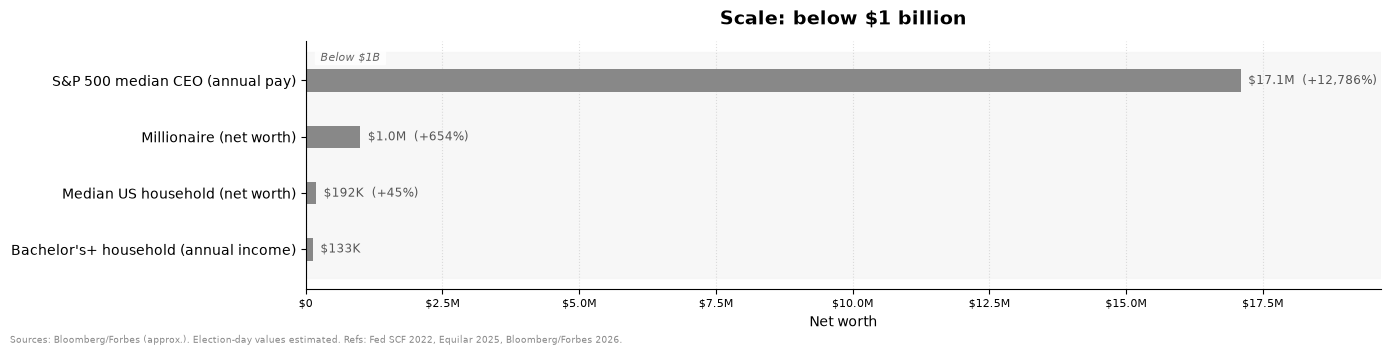

In [4]:
draw_chart(
    [GROUP_BELOW],
    "Scale: below $1 billion",
    ref_pct_baseline={"Below $1B": 0.0001327},
)

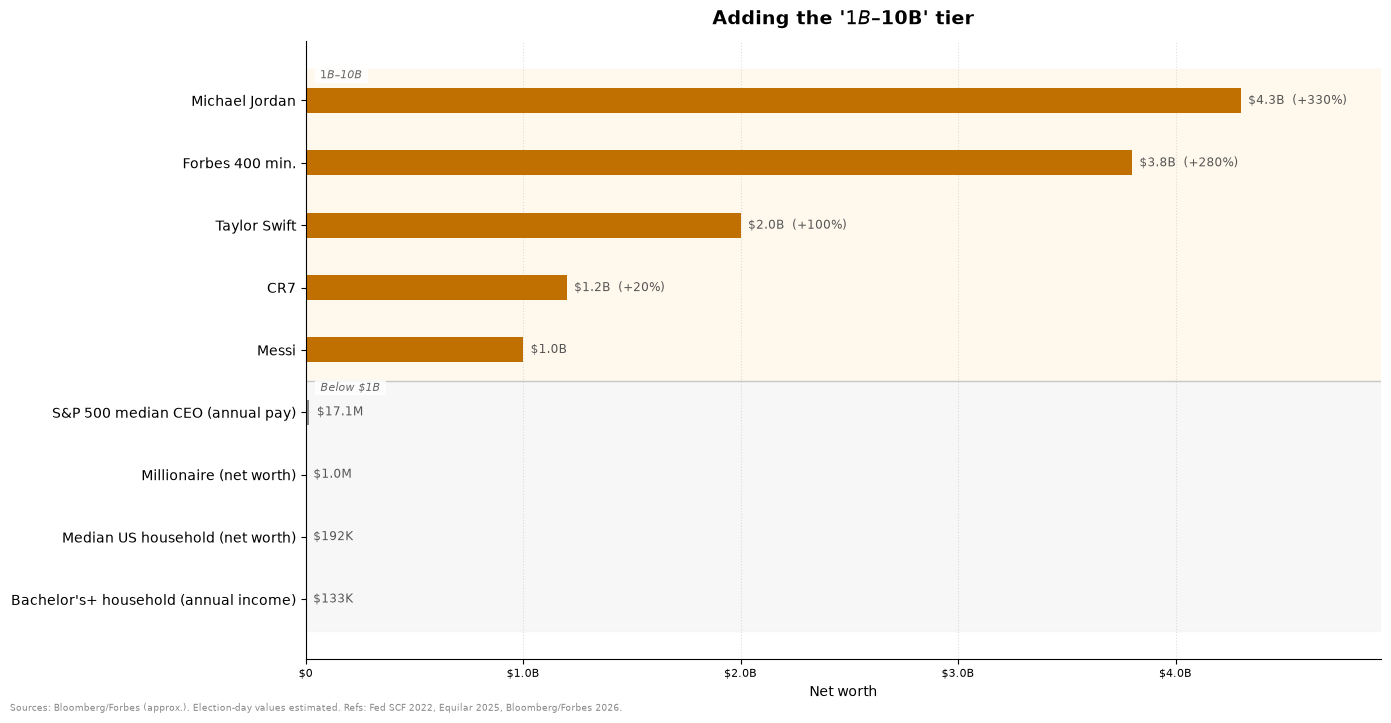

In [5]:
draw_chart(
    [GROUP_1B_10B, GROUP_BELOW],
    "Adding the '$1B – $10B' tier",
    ref_pct_baseline={"$1B – $10B": 1.0},
)

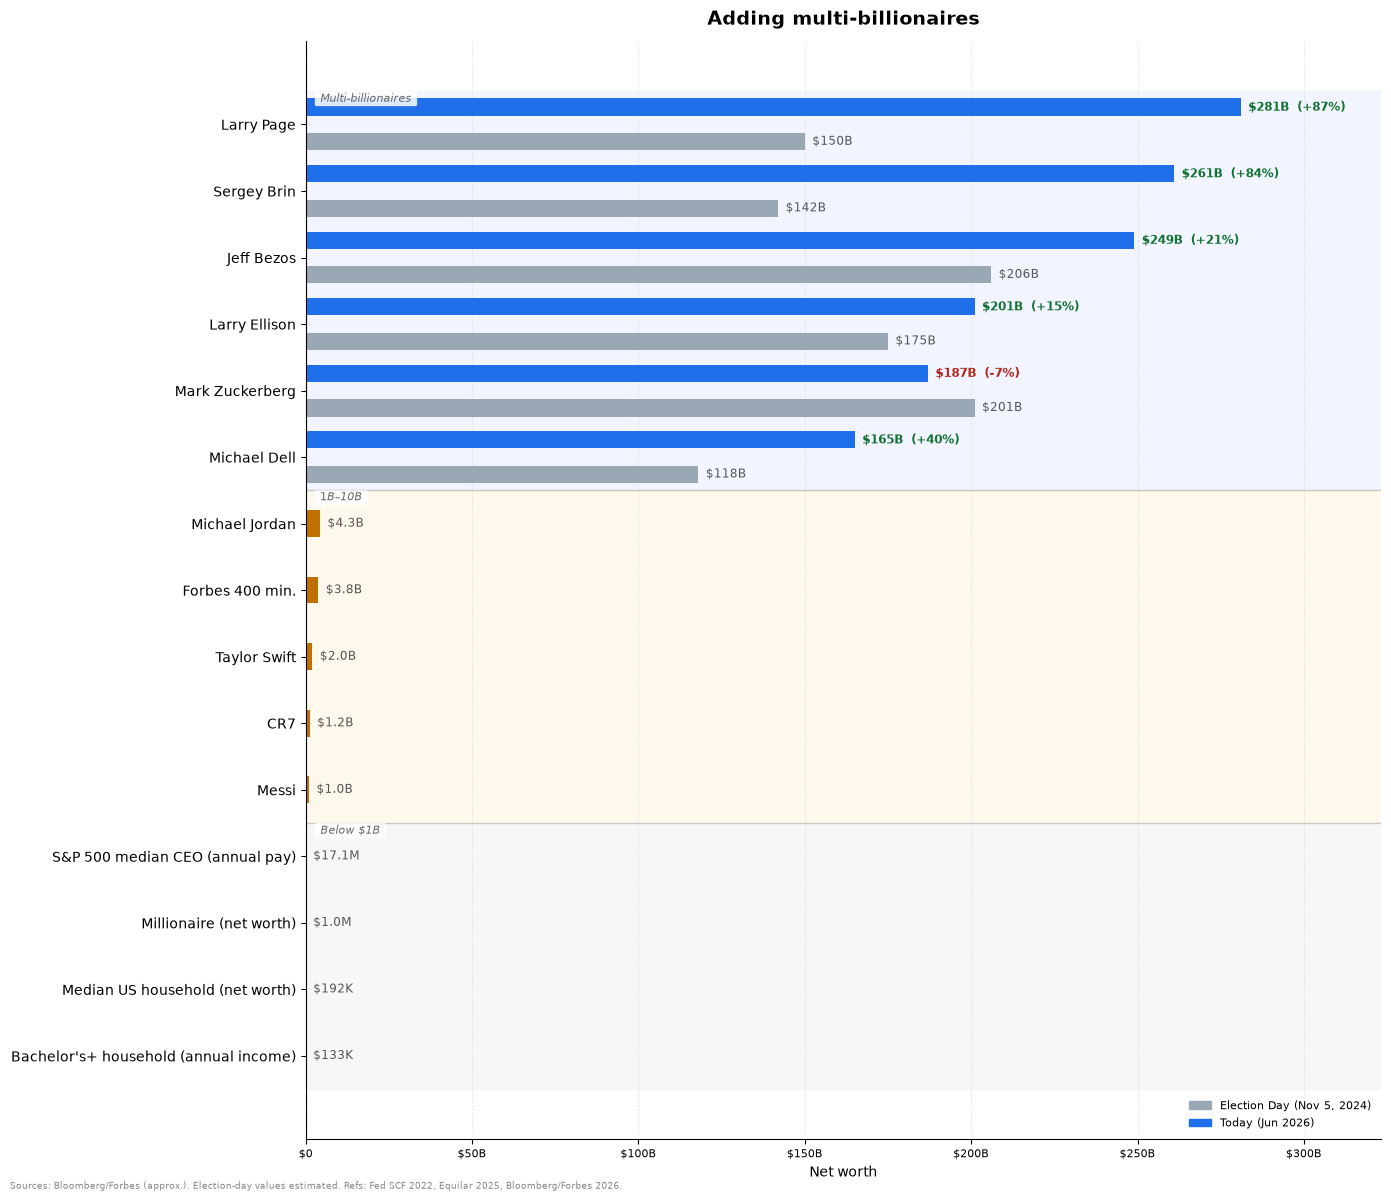

In [6]:
draw_chart(
    [GROUP_MULTI, GROUP_1B_10B, GROUP_BELOW],
    "Adding multi-billionaires",
)

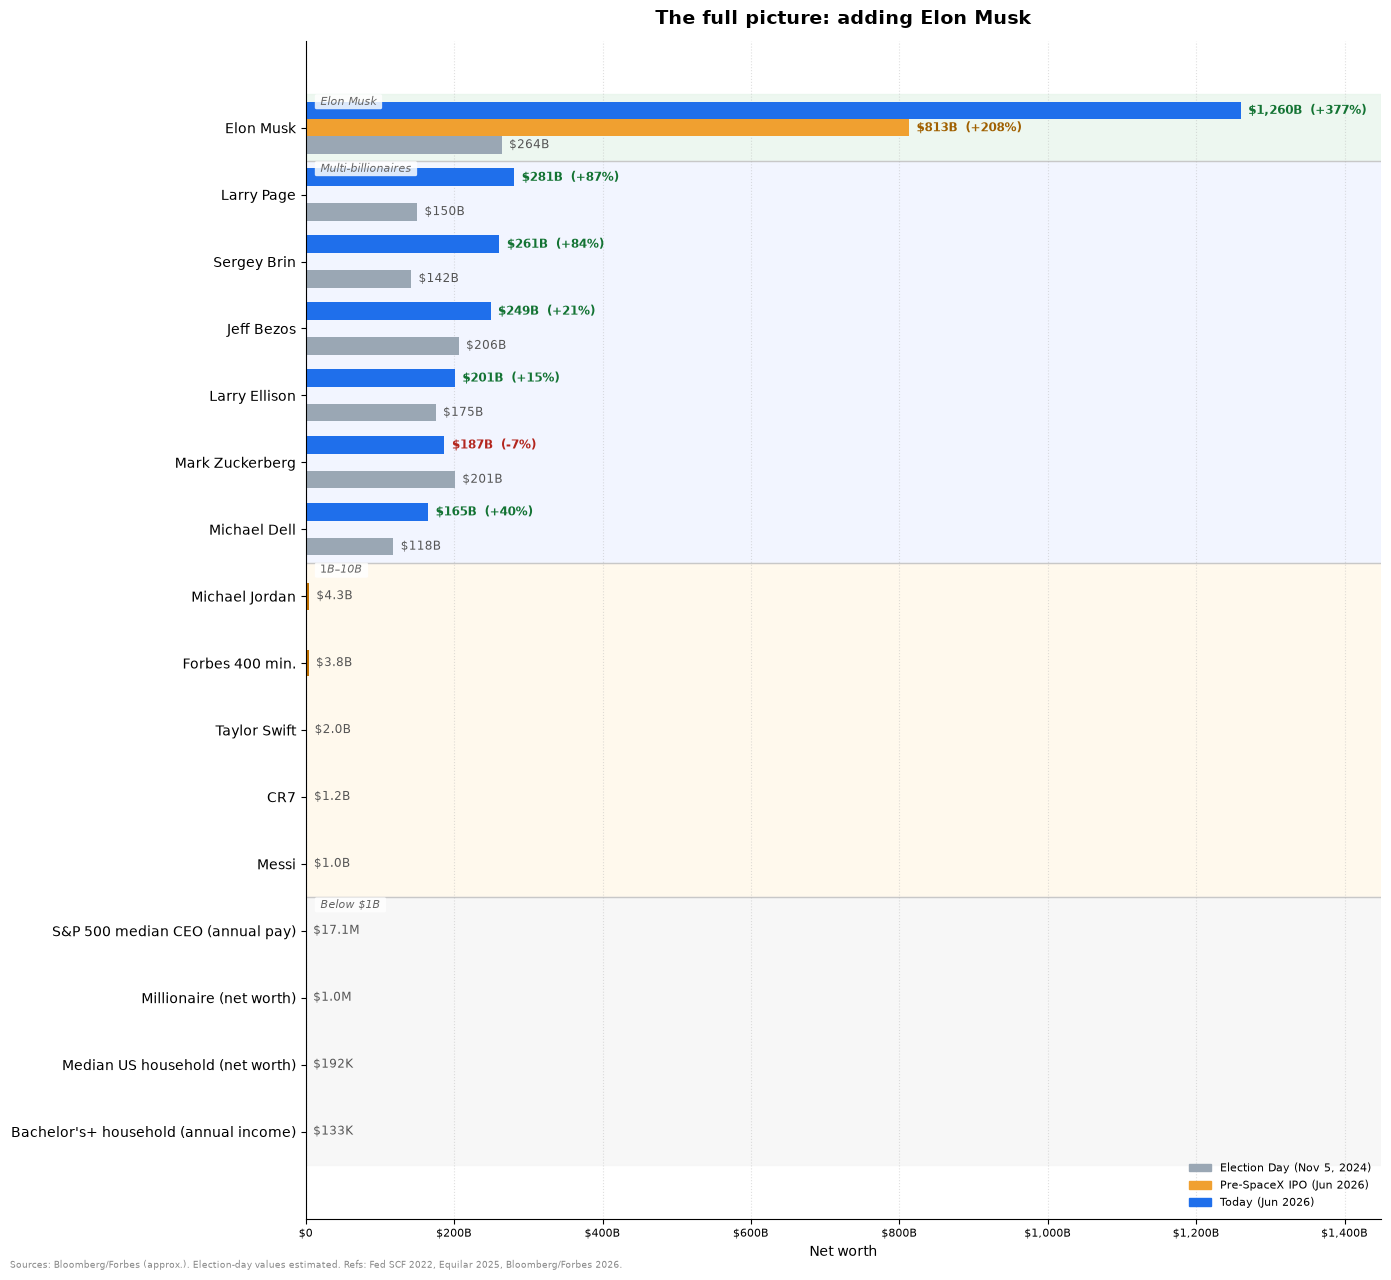

In [7]:
draw_chart(
    [GROUP_MUSK, GROUP_MULTI, GROUP_1B_10B, GROUP_BELOW],
    "The full picture: adding Elon Musk",
)